```
<06_more_apples.ipynb>

제미나이 의존도: 80-90%

예전에는 한 이미지에 단 하나의 사과만 있어서 모델학습하는 맛이 안났다.
한 이미지에 여러개의 사과가 있을때 여러개의 네모박스를 치는 모습을 보고싶었다.
그래서 이 코드에서 구현해 보았다.
우선 roboflow에서 apple 데이터셋을 구했는데, 단일 사과 사진도 있지만, 여러개의 사과 사진이 있는 데이터셋을 찾았다.
데이터는 약 150여개 였다.
저번에 3600여개 했을 때보단 확실히 줄었다. 지금은 완벽한 모델을 만드는 과정이 아니기 때문에 150여개로도 충분했다.
matplotlib 라이브러리로 테스트 이미지를 띄워 봤는데, conf, iou 값을 조절함에 따라 네모박스 치는게 달라져서 신기했다.
```

In [1]:
!pwd

/Users/jeongjaehun/Github/03_object_detection


In [5]:
import os
import cv2
from ultralytics import YOLO
import time

current_dir = os.getcwd()

model = YOLO("yolov8n.pt")

start_time = time.time()
results = model.train(
    data="dataset/data.yaml", 
    epochs=15, 
    imgsz=640, 
    device="mps",

    save=True, # 결과를 이미지로 저장
    project=os.path.join(current_dir, "runs"),
    name="apple_prediction"
)

end_time = time.time()
elapsed_time = int(end_time - start_time)
mins, secs = divmod(elapsed_time, 60)
print(f"소요시간: {mins}min {secs}sec")

New https://pypi.org/project/ultralytics/8.4.92 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.11.15 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=apple_prediction, nbs=64, nm

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

def inspect_detection(image_path, conf_threshold=0.25, iou_threshold=0.45):
    # conf와 iou 파라미터를 조절해가며 시각화 결과를 확인하는 함수입니다.

    # 모델 추론 수행 (파라미터 주입)
    preds = model.predict(
        source=image_path, 
        conf=conf_threshold, 
        iou=iou_threshold, 
        device="mps"
    )

    # 예측 결과가 그려진 이미지 가져오기 (OpenCV BGR 포맷)
    annotated_img = preds[0].plot()

    # Matplotlib 시각화를 위해 RGB로 변환
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # 화면 출력
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_img_rgb)
    plt.title(f"Conf: {conf_threshold} | IoU: {iou_threshold}", fontsize=14)
    plt.axis('off')
    plt.show()


image 1/1 /Users/jeongjaehun/Github/03_object_detection/dataset/test/images/n07740461_9844_jpg.rf.vEUK30sA4i4O6ZJJDFKU.jpg: 640x640 3 appless, 44.9ms
Speed: 10.6ms preprocess, 44.9ms inference, 26.2ms postprocess per image at shape (1, 3, 640, 640)


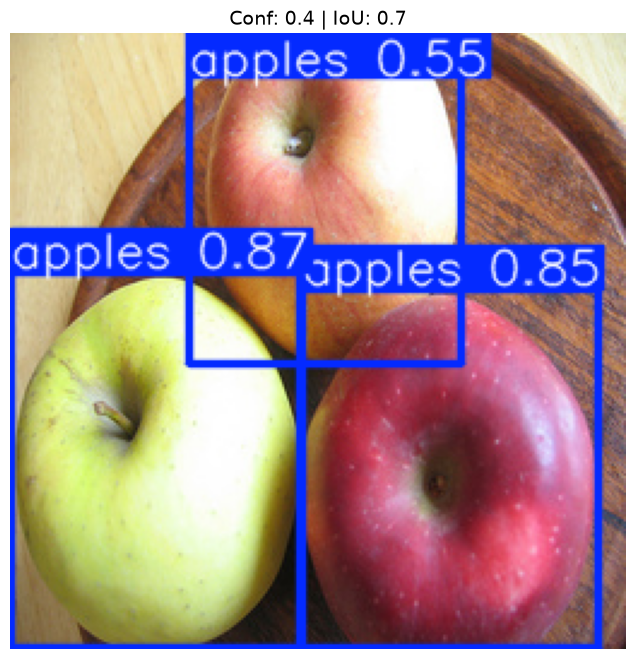

In [10]:
test_image = "dataset/test/images/n07740461_9844_jpg.rf.vEUK30sA4i4O6ZJJDFKU.jpg"

inspect_detection(test_image, conf_threshold=0.4, iou_threshold=0.7)

In [16]:
from ultralytics import YOLO

# 내가 만든 커스텀 yaml 지도를 모델에 주입
model = YOLO("dataset/my_test_yolo.yaml", task='detect')

# 요약본 출력
model.info()

WARNING ⚠️ no model scale passed. Assuming scale='n'.
my_test_YOLO summary: 24 layers, 88,281 parameters, 88,265 gradients, 4.6 GFLOPs


(24, 88281, 88265, 4.5907968)